# DL4ES: ReLU → LeakyReLU / PReLU → ELU / SELU

Цель ноутбука — на **очень глубокой** полносвязной сети показать, как выбор нелинейности влияет на:
- **смещение среднего** активаций по слоям;
- **эволюцию дисперсии** активаций по глубине (variance propagation);
- форму распределений (гистограммы).

Фокус: *статистика распределений активаций* (mean/var), а не качество на задаче.

## Ссылки на ключевые статьи
- **ELU**: Djork-Arné Clevert, Thomas Unterthiner, Sepp Hochreiter, *Fast and Accurate Deep Network Learning by Exponential Linear Units (ELUs)*, 2015, arXiv:1511.07289.
- **SELU**: Günter Klambauer, Thomas Unterthiner, Andreas Mayr, Sepp Hochreiter, *Self-Normalizing Neural Networks*, 2017, arXiv:1706.02515 (NeurIPS 2017).


In [1]:
# === Импорты и воспроизводимость ===
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from dataclasses import dataclass
from tqdm import tqdm

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 1) Синтетический вход

Чтобы изолировать эффект нелинейностей на **распределениях**, мы сначала будем смотреть не на датасет, а на прохождение случайного нормального входа через глубокую сеть.

Так проще увидеть:
- как быстро «уезжает» mean в положительную область;
- как «схлопывается» или «взрывается» variance.


In [2]:
# === Генерация входа ===
N = 8192      # размер батча для оценки распределений
D_IN = 128    # размерность входа
X = torch.randn(N, D_IN, device=device)  # ~ N(0, 1)
print("X mean:", X.mean().item(), "X var:", X.var(unbiased=False).item())


X mean: -0.0004883311339654028 X var: 1.0002994537353516


## 2) Глубокая MLP для анализа распределений

Мы построим сеть из `depth` линейных слоёв одинаковой ширины и будем измерять статистики
активаций **после** нелинейности на каждом слое.

Важная деталь: для корректного сравнения используем **одинаковую инициализацию**.

- Для ReLU/Leaky/PReLU обычно применяют He-init.
- Для SELU в оригинальной работе используется LeCun normal (и AlphaDropout). Здесь мы
  сделаем два режима: (A) общий He-init для честного сравнения; (B) «рекомендуемый» LeCun-init для SELU.


In [3]:
@dataclass
class LayerStats:
    layer: int
    mean: float
    var: float

In [4]:
class DeepMLPStats(nn.Module):
    def __init__(self, d_in=128, width=256, depth=60, act="relu", init="he", alpha_leaky=0.01):
        super().__init__()
        assert act in ["relu", "leaky_relu", "prelu", "elu", "selu"]
        assert init in ["he", "lecun"]

        self.act_name = act
        self.depth = depth
        self.alpha_leaky = alpha_leaky
        self.prelu = nn.PReLU(num_parameters=1, init=alpha_leaky) if act == "prelu" else None

        self.layers = nn.ModuleList([nn.Linear(d_in if i==0 else width, width) for i in range(depth)])
        self._last_stats = []

        self.reset_parameters(init=init)

    def reset_parameters(self, init="he"):
        for lin in self.layers:
            if init == "he":
                nn.init.kaiming_normal_(lin.weight, nonlinearity="relu")
                nn.init.zeros_(lin.bias)
            else:
                fan_in = lin.weight.size(1)
                nn.init.normal_(lin.weight, mean=0.0, std=math.sqrt(1.0/fan_in))
                nn.init.zeros_(lin.bias)

    def act(self, z):
        if self.act_name == "relu":
            return F.relu(z)
        if self.act_name == "leaky_relu":
            return F.leaky_relu(z, negative_slope=self.alpha_leaky)
        if self.act_name == "prelu":
            return self.prelu(z)
        if self.act_name == "elu":
            return F.elu(z, alpha=1.0)
        if self.act_name == "selu":
            return F.selu(z)
        raise ValueError("Unknown activation")

    @torch.no_grad()
    def forward_collect(self, x):
        self._last_stats = []
        h = x
        for i, lin in enumerate(self.layers):
            z = lin(h)
            a = self.act(z)
            self._last_stats.append(LayerStats(i, a.mean().item(), a.var(unbiased=False).item()))
            h = a
        return h

    @torch.no_grad()
    def last_stats(self):
        return self._last_stats

In [5]:
def run_collect(act, init="he", depth=60, width=256, alpha_leaky=0.01):
    m = DeepMLPStats(d_in=D_IN, width=width, depth=depth, act=act, init=init, alpha_leaky=alpha_leaky).to(device)
    _ = m.forward_collect(X)
    stats = m.last_stats()
    return m, stats

## 3) Эксперимент 1: общий режим инициализации (He-init)

Сравним все функции при **одинаковой** инициализации (He), чтобы увидеть *чистый эффект нелинейности*
на смещение среднего и дисперсию.


In [6]:
DEPTH = 60
WIDTH = 256

In [7]:
acts = ["relu", "leaky_relu", "prelu", "elu", "selu"]
stats_he = {}

In [15]:
for act in acts:
    m, st = run_collect(act, init="he" if act != "selu" else "lecun", depth=DEPTH, width=WIDTH, alpha_leaky=0.01)
    stats_he[act] = {"model": m, "stats": st}

In [16]:
# sanity: первые слои
for act in acts:
    s0 = stats_he[act]["stats"][0]
    s10 = stats_he[act]["stats"][10]
    print(act, "| layer0 mean/var:", (round(s0.mean,4), round(s0.var,4)),
          "| layer10 mean/var:", (round(s10.mean,4), round(s10.var,4)))

relu | layer0 mean/var: (0.5639, 0.6835) | layer10 mean/var: (0.6717, 1.1867)
leaky_relu | layer0 mean/var: (0.5592, 0.6935) | layer10 mean/var: (0.6827, 0.9813)
prelu | layer0 mean/var: (0.5558, 0.6853) | layer10 mean/var: (0.3404, 0.3709)
elu | layer0 mean/var: (0.2774, 1.123) | layer10 mean/var: (0.6251, 3.2332)
selu | layer0 mean/var: (-0.0014, 0.9915) | layer10 mean/var: (-0.0003, 1.0074)


In [ ]:
def plot_mean_var(stats_dict, title_prefix=""):
    # mean
    plt.figure()
    for act, payload in stats_dict.items():
        st = payload["stats"]
        layers = [x.layer for x in st]
        means = [x.mean for x in st]
        plt.plot(layers, means, label=act)
    plt.xlabel("layer index")
    plt.ylabel("mean activation")
    plt.title(f"{title_prefix}Mean by layer")
    plt.legend()
    plt.show()

    # var
    plt.figure()
    for act, payload in stats_dict.items():
        st = payload["stats"]
        layers = [x.layer for x in st]
        vars_ = [x.var for x in st]
        plt.plot(layers, vars_, label=act)
    plt.yscale("log")
    plt.xlabel("layer index")
    plt.ylabel("var activation (log scale)")
    plt.title(f"{title_prefix}Variance by layer")
    plt.legend()
    plt.show()

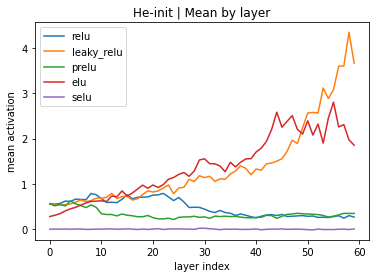

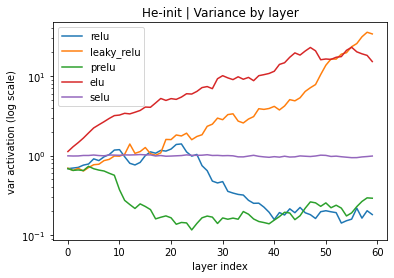

In [17]:
plot_mean_var(stats_he, title_prefix="He-init | ")

## 4) Гистограммы распределений активаций на выбранных слоях

Чтобы увидеть *форму* распределений, построим гистограммы активаций для нескольких глубин.

- Ранний слой: 0
- Средний: depth//2
- Глубокий: depth-1

Ожидаемые наблюдения:
- у ReLU-family распределение «обрезается» слева и mean уезжает в плюс;
- ELU/SELU возвращают отрицательную область и могут стабилизировать mean/var.


In [11]:
@torch.no_grad()
def activations_at_layer(model: DeepMLPStats, layer_idx: int, x: torch.Tensor):
    h = x
    for i, lin in enumerate(model.layers):
        z = lin(h)
        a = model.act(z)
        if i == layer_idx:
            return a.detach().flatten()
        h = a
    return h.detach().flatten()

In [12]:
def plot_histograms(stats_payload, layers_to_show, bins=100, xlim=(-5, 5), title=""):
    for act, payload in stats_payload.items():
        model = payload["model"]
        for li in layers_to_show:
            a = activations_at_layer(model, li, X).cpu().numpy()
            plt.figure()
            plt.hist(a, bins=bins)
            plt.xlim(*xlim)
            plt.title(f"{title}{act} | layer {li}")
            plt.xlabel("activation value")
            plt.ylabel("count")
            plt.show()

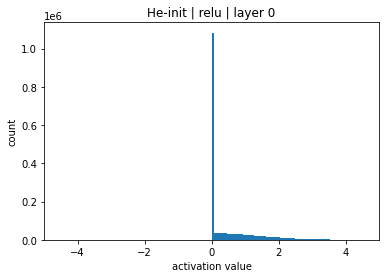

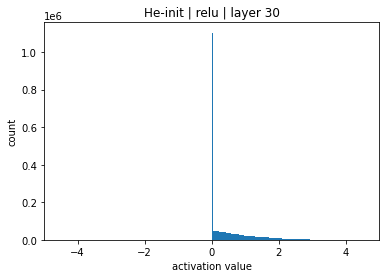

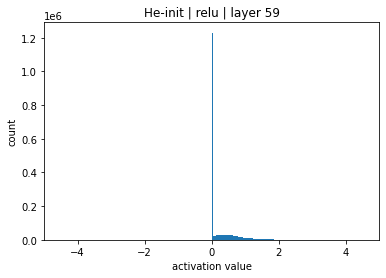

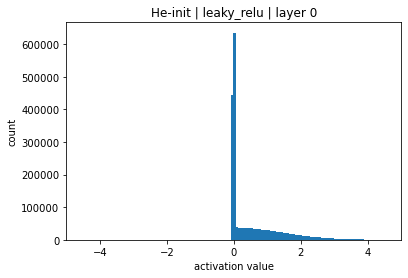

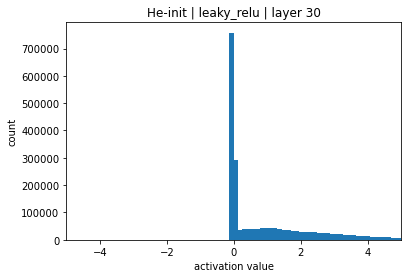

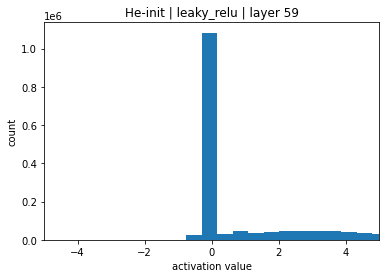

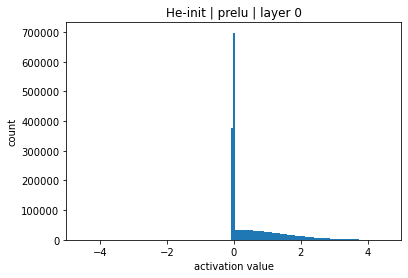

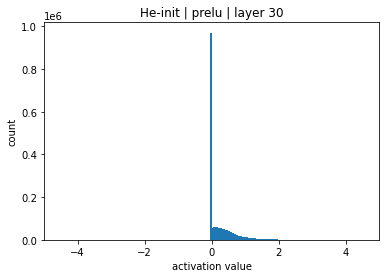

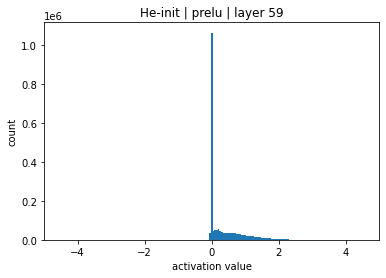

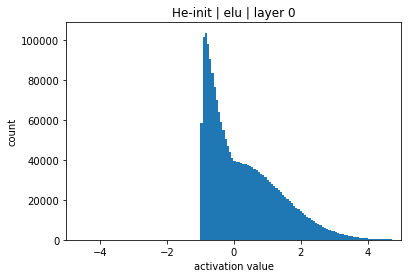

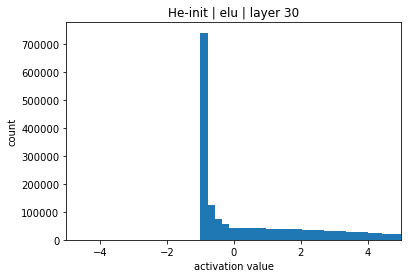

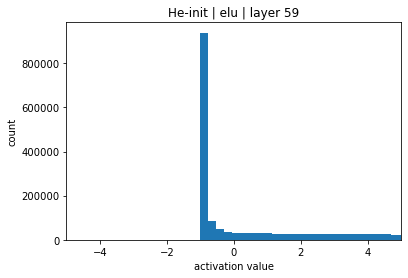

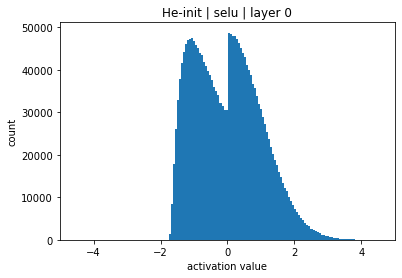

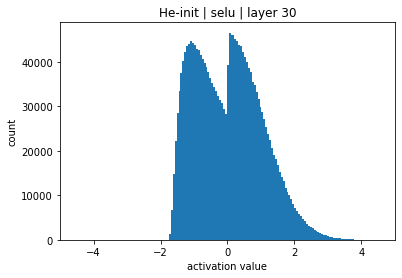

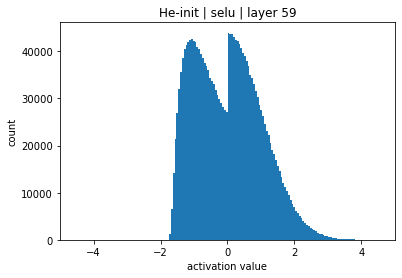

In [18]:
layers_show = [0, DEPTH//2, DEPTH-1]
plot_histograms(stats_he, layers_show, bins=120, xlim=(-5, 5), title="He-init | ")

## 5) Эксперимент 2: SELU в «рекомендуемом» режиме (LeCun init)

В работе про SELU (Self-Normalizing Neural Networks) ключевая идея: при определённых условиях
нелинейность + инициализация приводят к **самонормализации**: mean≈0 и var≈1 сохраняются по глубине.

Сравним:
- SELU + He-init (как в эксперименте 1)
- SELU + LeCun-init (как рекомендуют для SNN)

Замечание: мы здесь смотрим именно на статистики прохождения, без AlphaDropout.


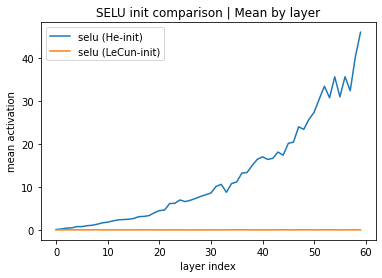

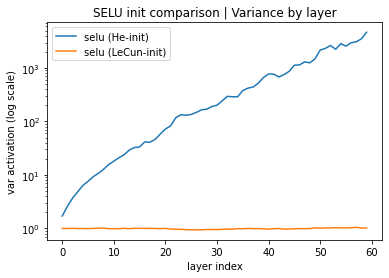

In [14]:
stats_selu_compare = {}

m_he, st_he = run_collect("selu", init="he", depth=DEPTH, width=WIDTH)
m_lc, st_lc = run_collect("selu", init="lecun", depth=DEPTH, width=WIDTH)

stats_selu_compare["selu (He-init)"] = {"model": m_he, "stats": st_he}
stats_selu_compare["selu (LeCun-init)"] = {"model": m_lc, "stats": st_lc}

plot_mean_var(stats_selu_compare, title_prefix="SELU init comparison | ")



1) **ReLU**: сильное *положительное смещение* средних.

2) **LeakyReLU / PReLU**: возвращают отрицательную область → снижают смещение средних, распределение менее «однобокое».

3) **ELU**: экспоненциальный отрицательный хвост → mean ближе к 0, изменяется динамика дисперсии.

4) **SELU**: при согласованных предпосылках (в т.ч. LeCun-init) стремится удерживать mean≈0 и var≈1 по глубине.